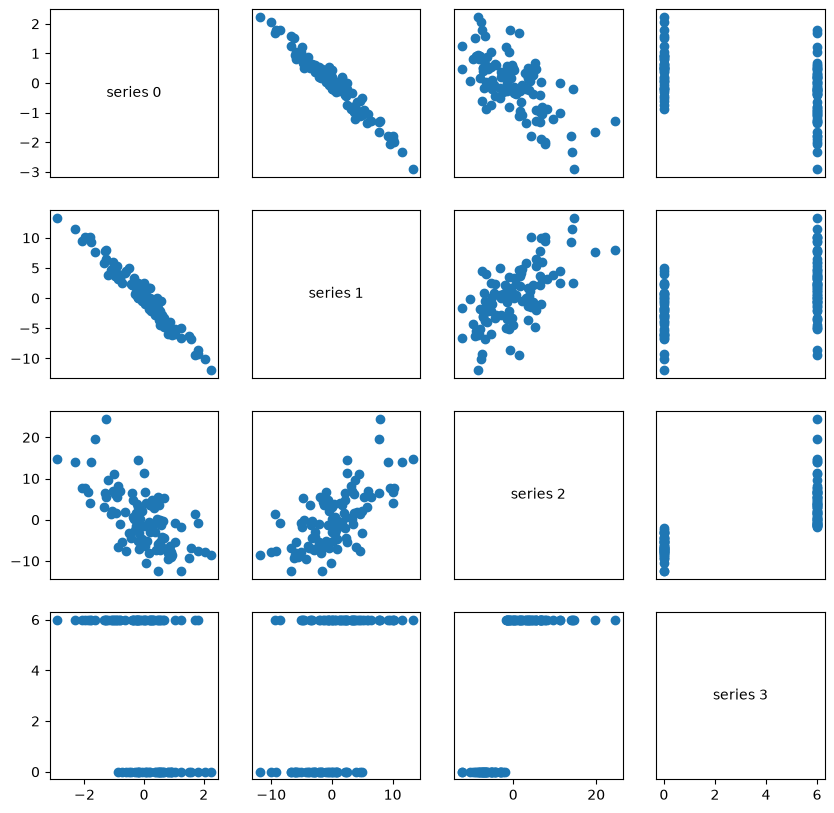

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

def random_normal():
    """Returns a random draw from a standard normal distribution"""
    return random.gauss(0, 1)

def random_row():
    row = [None, None, None, None]
    row[0] = random_normal()
    row[1] = -5 * row[0] + random_normal()
    row[2] = row[0] + row[1] + 5 * random_normal()
    row[3] = 6 if row[2] > -2 else 0
    return row

def shape(data):
    """Returns the shape of the data as (num_rows, num_columns)"""
    num_rows = len(data)
    num_columns = len(data[0]) if data else 0
    return num_rows, num_columns
def get_column(data, i):
    """Returns the ith column of data (as a list)"""
    return [data[row][i] for row in range(len(data))]

def correlation(column1, column2):
    """Returns the correlation between two columns of data"""
    return np.corrcoef(column1, column2)[0, 1]

def make_matrix(num_rows, num_columns, entry_fn):
    """Returns a num_rows x num_columns matrix
    whose (i, j)th entry is entry_fn(i, j)"""
    return [[entry_fn(i, j) for j in range(num_columns)]
            for i in range(num_rows)]

def correlation_matrix(data):
    """Returns the num_columns x num_columns matrix whose (i, j)th entry
    is the correlation between columns i and j of data"""
    num_rows, num_columns = shape(data)

    def matrix_entry(i, j):
        return correlation(get_column(data, i), get_column(data, j))

    return make_matrix(num_columns, num_columns, matrix_entry)

num_points = 100

# 가상의 데이터 생성
random.seed(0)
data = [random_row() for _ in range(num_points)]

# 상관 행렬 계산
correlation_mat = correlation_matrix(data)

# 시각화 (산점도 행렬)
_, num_columns = shape(data)
fig, ax = plt.subplots(num_columns, num_columns, figsize=(10, 10))

for i in range(num_columns):
    for j in range(num_columns):
        if i != j:
            ax[i, j].scatter(get_column(data, j), get_column(data, i))
        else:
            ax[i, j].annotate("series " + str(i), (0.5, 0.5),
                              xycoords='axes fraction',
                              ha="center", va="center")        
        if i < num_columns - 1:
            ax[i, j].xaxis.set_visible(False)
        if j > 0:
            ax[i, j].yaxis.set_visible(False)

ax[-1, -1].set_xlim(ax[0, -1].get_xlim())
ax[0, 0].set_ylim(ax[0, 1].get_ylim())

plt.show()